<a href="https://colab.research.google.com/github/mschlemper/Alura-Store-MARCO-AURELIO-SCHLEMPER/blob/main/miniProjeto_ESBOCO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
# Abrindo nossas caixas de ferramentas
import pandas as pd       # Para mexer com tabelas (DataFrames)
import numpy as np        # Para fazer contas matemáticas
import matplotlib.pyplot as plt  # Para desenhar gráficos simples
import seaborn as sns     # Para deixar os gráficos mais bonitos e modernos
import json               # Para ler e salvar arquivos de texto no formato JSON
import random             # Para gerar números aleatórios
from datetime import datetime, timedelta  # Para mexer com datas e prazos

RF01 – Criar o Dataset de Vendas (Nossa Tabela de Dados)
Como não temos uma tabela pronta, vamos criar uma "tabela simulada" com dados de vendas de uma loja de eletrônicos para podermos treinar. Vamos gerar 100 linhas de vendas fictícias.

Nota de Iniciante: Um DataFrame é apenas o nome chique que o Python dá para uma tabela parecida com o Excel (com linhas e colunas).

In [7]:
def criar_dataset_vendas():
    # Garantir que os números gerados sejam sempre os mesmos para o teste não mudar
    np.random.seed(42)
    random.seed(42)

    # Criando 100 IDs de clientes e produtos fictícios
    clientes = [f"CLI_{random.randint(1000, 1100)}" for _ in range(100)]
    produtos = random.choices(["Notebook", "Smartphone", "Tablet", "Monitor", "Teclado"], k=100)

    # Gerando quantidades (entre 1 e 5) e preços base
    quantidades = np.random.randint(1, 6, size=100)
    precos_base = {"Notebook": 4000, "Smartphone": 2500, "Tablet": 1500, "Monitor": 1200, "Teclado": 200}
    precos_unitarios = [precos_base[p] for p in produtos]

    # Criando datas de vendas nos últimos 6 meses
    data_final = datetime.now()
    datas = [data_final - timedelta(days=int(np.random.randint(0, 180))) for _ in range(100)]

    # Montando a tabela estruturada
    dados = {
        "ID_Cliente": clientes,
        "Produto": produtos,
        "Quantidade": quantidades,
        "Preco_Unitario": precos_unitarios,
        "Data_Venda": datas
    }

    df = pd.DataFrame(dados)

    # Inserindo alguns erros de propósito (valores faltando) para podermos limpar depois!
    df.loc[10, "Quantidade"] = np.nan
    df.loc[25, "Preco_Unitario"] = np.nan

    # Inserindo alguns preços absurdamente altos (Outliers) para testar nossa detecção
    df.loc[5, "Preco_Unitario"] = 50000
    df.loc[50, "Preco_Unitario"] = 35000

    return df

# Criando a tabela e guardando na variável 'df_vendas'
df_vendas = criar_dataset_vendas()
print("Tabela criada com sucesso!")

Tabela criada com sucesso!


RF02 – Inspecionar e Descrever os Dados (Espiar a Tabela)
Antes de fazer qualquer análise, precisamos olhar para a nossa tabela para entender o que tem dentro dela. Vamos criar uma função que mostra as 5 primeiras linhas, o tipo de cada coluna e um resumo matemático.

In [8]:
def inspecionar_dados(df):
    print("--- 1. Primeiras 5 linhas da tabela: ---")
    display(df.head()) # O head() mostra o 'cabeçalho' dos dados

    print("\n--- 2. Informações das colunas (Tipos e valores guardados): ---")
    df.info() # Mostra se a coluna é texto, número, data, etc.

    print("\n--- 3. Resumo Estatístico (Média, Mínimo, Máximo): ---")
    display(df.describe()) # Faz uma mágica matemática e resume os números para nós

# Executando a inspeção
inspecionar_dados(df_vendas)

--- 1. Primeiras 5 linhas da tabela: ---


,ID_Cliente,Produto,Quantidade,Preco_Unitario,Data_Venda
0,CLI_1081,Tablet,4.0,1500.0,2026-05-23 02:02:58.383612
1,CLI_1014,Smartphone,5.0,2500.0,2026-02-05 02:02:58.383612
2,CLI_1003,Teclado,3.0,200.0,2026-04-09 02:02:58.383612
3,CLI_1094,Monitor,5.0,1200.0,2026-06-08 02:02:58.383612
4,CLI_1035,Smartphone,5.0,2500.0,2026-01-09 02:02:58.383612



--- 2. Informações das colunas (Tipos e valores guardados): ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   ID_Cliente      100 non-null    object        
 1   Produto         100 non-null    object        
 2   Quantidade      99 non-null     float64       
 3   Preco_Unitario  99 non-null     float64       
 4   Data_Venda      100 non-null    datetime64[ns]
dtypes: datetime64[ns](1), float64(2), object(2)
memory usage: 4.0+ KB

--- 3. Resumo Estatístico (Média, Mínimo, Máximo): ---


,Quantidade,Preco_Unitario,Data_Venda
count,99.000000,99.000000,100
mean,3.060606,2578.787879,2026-03-18 06:50:58.383611392
min,1.000000,200.000000,2025-12-22 02:02:58.383612
25%,2.000000,1200.000000,2026-02-07 14:02:58.383611904
50%,3.000000,1500.000000,2026-03-12 02:02:58.383611904
75%,4.000000,2500.000000,2026-04-30 20:02:58.383611904
max,5.000000,50000.000000,2026-06-19 02:02:58.383612
std,1.405660,5998.252683,NaN


RF03 – Limpar e Tratar os Dados (Corrigindo os Erros)
Lembra que colocamos valores vazios (NaN) de propósito? Agora vamos corrigi-los:

Se faltar a Quantidade, vamos assumir que foi comprado pelo menos 1 item.

Se faltar o Preço Unitário, vamos preencher com a média de preço daquele produto específico.

In [9]:
def limpar_dados(df):
    # Fazendo uma cópia para não estragar a tabela original
    df_limpo = df.copy()

    # 1. Se a quantidade estiver vazia, mudamos para 1
    df_limpo["Quantidade"] = df_limpo["Quantidade"].fillna(1)

    # 2. Se o preço estiver vazio, pegamos a média de preço daquele produto
    df_limpo["Preco_Unitario"] = df_limpo.groupby("Produto")["Preco_Unitario"].transform(lambda x: x.fillna(x.mean()))

    print("Dados limpos! Valores vazios foram preenchidos.")
    return df_limpo

# Aplicando a limpeza
df_vendas_limpo = limpar_dados(df_vendas)

Dados limpos! Valores vazios foram preenchidos.


RF04 – Detectar e Tratar Outliers (Duas Versões)Aqui nós vamos encontrar aqueles preços falsos de $50.000$ e $35.000$ que colocamos de propósito e tratá-los de duas formas diferentes.

In [10]:
# Versão 1: Descobrir quem é absurdo usando a técnica do IQR (Intervalo Interquartil)
# E substituir esses valores pela mediana dos preços normais.
def tratar_outliers_v1(df):
    df_v1 = df.copy()

    # Contas matemáticas para descobrir o limite do que é um preço "normal"
    Q1 = df_v1["Preco_Unitario"].quantile(0.25)
    Q3 = df_v1["Preco_Unitario"].quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + 1.5 * IQR

    # Quem passar do limite superior vira a mediana (o valor do meio)
    mediana = df_v1["Preco_Unitario"].median()
    df_v1.loc[df_v1["Preco_Unitario"] > limite_superior, "Preco_Unitario"] = mediana

    print(class_name := "Outliers tratados com a Versão 1 (Substituição pela Mediana)!")
    return df_v1

# Versão 2: Em vez de usar a mediana, vamos usar a média mais 3 desvios padrões
# E vamos apenas "cortar" (limitar) o preço até o teto máximo permitido.
def tratar_outliers_v2(df):
    df_v2 = df.copy()

    # Outra forma matemática de achar o limite do que é aceitável
    media = df_v2["Preco_Unitario"].mean()
    desvio = df_v2["Preco_Unitario"].std()
    limite_superior = media + 3 * desvio

    # Quem for maior que o limite, ganha exatamente o valor do limite (Capping)
    df_v2["Preco_Unitario"] = df_v2["Preco_Unitario"].clip(upper=limite_superior)

    print("Outliers tratados com a Versão 2 (Capping pelo limite superior)!")
    return df_v2

# Vamos escolher a Versão 1 para seguir o projeto, que é mais comum
df_vendas_sem_outliers = tratar_outliers_v1(df_vendas_limpo)

Outliers tratados com a Versão 1 (Substituição pela Mediana)!


RF05 – Criar Colunas Derivadas (Novas Informações)Agora que os preços estão corrigidos, vamos criar colunas novas para descobrir:Valor_Total: Quanto deu a venda (Quantidade $\times$ Preço Unitário).Mes: Em qual mês do ano aquela venda aconteceu.

In [11]:
def criar_colunas_derivadas(df):
    df_novas = df.copy()

    # Multiplicando a quantidade pelo preço para ter o total da nota
    df_novas["Valor_Total"] = df_novas["Quantidade"] * df_novas["Preco_Unitario"]

    # Extraindo o mês da data para sabermos quando vendeu mais
    df_novas["Mes"] = df_novas["Data_Venda"].dt.strftime("%Y-%m")

    print("Novas colunas 'Valor_Total' e 'Mes' criadas com sucesso!")
    return df_novas

# Aplicando a criação das colunas
df_vendas_calculado = criar_colunas_derivadas(df_vendas_sem_outliers)

Novas colunas 'Valor_Total' e 'Mes' criadas com sucesso!


RF06 & RF07 – Agrupar e Segmentar (Quem gasta mais?)
Vamos descobrir o total vendido por mês e também carimbar cada cliente de acordo com o bolso dele:

Gastou menos de 2000? Bronze

Gastou entre 2000 e 5000? Prata

Gastou mais de 5000? Ouro

In [12]:
def calcular_metricas_e_segmentar(df):
    # RF06: Agrupando para ver o total por mês (Igual tabela dinâmica do Excel)
    vendas_por_mes = df.groupby("Mes")["Valor_Total"].sum().reset_index()
    print("--- Vendas Totais por Mês ---")
    print(vendas_por_mes)

    # RF07: Somando o quanto cada cliente gastou no total
    gasto_cliente = df.groupby("ID_Cliente")["Valor_Total"].sum().reset_index()

    # Função interna para dar o "selo" do cliente
    def definir_categoria(valor):
        if valor < 2000:
            return "Bronze"
        elif valor <= 5000:
            return "Prata"
        else:
            return "Ouro"

    gasto_cliente["Segmento"] = gasto_cliente["Valor_Total"].apply(definir_categoria)

    print("\n--- Segmentação dos Clientes (Primeiras linhas) ---")
    display(gasto_cliente.head())

    return vendas_por_mes, gasto_cliente

# Executando os agrupamentos
df_mes, df_clientes = calcular_metricas_e_segmentar(df_vendas_calculado)

--- Vendas Totais por Mês ---
       Mes  Valor_Total
0  2025-12      50900.0
1  2026-01      79100.0
2  2026-02     133200.0
3  2026-03      62700.0
4  2026-04      78500.0
5  2026-05      97900.0
6  2026-06      41700.0

--- Segmentação dos Clientes (Primeiras linhas) ---


,ID_Cliente,Valor_Total,Segmento
0,CLI_1000,7500.0,Ouro
1,CLI_1003,2800.0,Prata
2,CLI_1004,6000.0,Ouro
3,CLI_1005,3800.0,Prata
4,CLI_1008,10000.0,Ouro


RF08 – Calcular Estatísticas com NumPy
Aqui vamos usar funções matemáticas puras para extrair três informações importantes sobre os preços normais dos produtos (sem os valores absurdos): a média, o valor do meio (mediana) e o desvio padrão.

In [14]:
# Usando o NumPy para fazer contas rápidas nas colunas
precos_normais = df_vendas_calculado["Preco_Unitario"].to_numpy()

media_np = np.mean(precos_normais)
mediana_np = np.median(precos_normais)
desvio_np = np.std(precos_normais)

print("--- Estatísticas Gerais dos Preços (NumPy) ---")
print(f"Média dos preços: R$ {media_np:.2f}")
print(f"Mediana dos preços: R$ {mediana_np:.2f}")
print(f"Desvio Padrão dos preços: R$ {desvio_np:.2f}")

--- Estatísticas Gerais dos Preços (NumPy) ---
Média dos preços: R$ 1748.00
Mediana dos preços: R$ 1500.00
Desvio Padrão dos preços: R$ 1266.92


RF09 – Criar Visualizações (Gráficos Visuais)
Vamos gerar dois gráficos bem bonitos e explicativos para colocar no projeto:

Um Gráfico de Barras mostrando o total vendido em cada mês.

Um Gráfico de Dispersão (Scatter Plot) relacionando a Quantidade comprada com o Valor Total, colorido por tipo de produto.

/tmp/ipykernel_646/3488496081.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_mes, x="Mes", y="Valor_Total", palette="Blues_d")


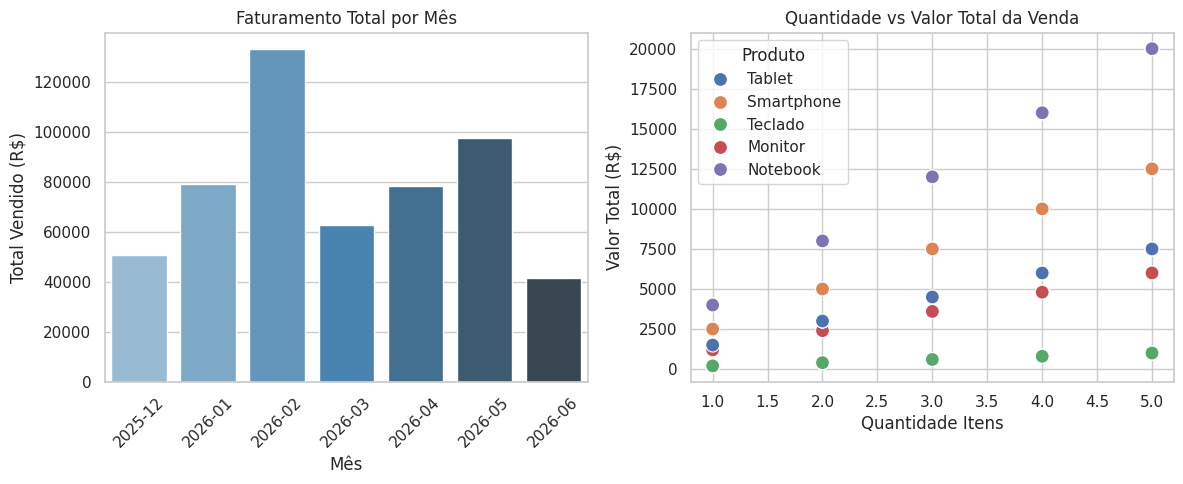

In [15]:
# Configurando o tamanho e estilo dos gráficos
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 5))

# 1. Gráfico de Barras: Vendas por Mês
plt.subplot(1, 2, 1) # Lado esquerdo
sns.barplot(data=df_mes, x="Mes", y="Valor_Total", palette="Blues_d")
plt.title("Faturamento Total por Mês")
plt.xlabel("Mês")
plt.ylabel("Total Vendido (R$)")
plt.xticks(rotation=45)

# 2. Gráfico de Dispersão: Quantidade vs Valor Total
plt.subplot(1, 2, 2) # Lado direito
sns.scatterplot(data=df_vendas_calculado, x="Quantidade", y="Valor_Total", hue="Produto", s=100)
plt.title("Quantidade vs Valor Total da Venda")
plt.xlabel("Quantidade Itens")
plt.ylabel("Valor Total (R$)")

# Ajusta o espaçamento e mostra na tela
plt.tight_layout()
plt.show()

RF11 & RF12 – Salvar os Resultados Finais
Por fim, o projeto pede para exportarmos os dados gerados para que outras pessoas consigam abrir em arquivos separados. Vamos salvar:

A tabela de vendas final calculada (dataset_final.csv)

O faturamento por mês (metricas_por_mes.csv)

A lista com os segmentos dos clientes (segmentacao_clientes.csv)

As estatísticas do NumPy salvas em um arquivo de texto estruturado (estatisticas_gerais.json)

In [16]:
# 1. Salvando as tabelas em formato CSV (Excel lê perfeitamente)
df_vendas_calculado.to_csv("dataset_final.csv", index=False)
df_mes.to_csv("metricas_por_mes.csv", index=False)
df_clientes.to_csv("segmentacao_clientes.csv", index=False)

# 2. Montando o dicionário para salvar em formato JSON
dicionario_estatisticas = {
    "media_preco": float(media_np),
    "mediana_preco": float(mediana_np),
    "desvio_padrao_preco": float(desvio_np),
    "total_registros_processados": len(df_vendas_calculado)
}

# Escrevendo no arquivo JSON
with open("estatisticas_gerais.json", "w", encoding="utf-8") as f:
    json.dump(dicionario_estatisticas, f, indent=4, ensure_ascii=False)

print("Parabéns! Todos os arquivos finais (.csv e .json) foram gerados e salvos no seu diretório!")

Parabéns! Todos os arquivos finais (.csv e .json) foram gerados e salvos no seu diretório!


[Pipeline] Iniciando processamento dos dados...

=== [RF02] Primeiras 5 linhas ===


,ID_Cliente,Produto,Quantidade,Preco_Unitario,Data_Venda
0,CLI_1081,Tablet,4.0,1500.0,2026-05-23 02:38:04.436134
1,CLI_1014,Smartphone,5.0,2500.0,2026-02-05 02:38:04.436134
2,CLI_1003,Teclado,3.0,200.0,2026-04-09 02:38:04.436134
3,CLI_1094,Monitor,5.0,1200.0,2026-06-08 02:38:04.436134
4,CLI_1035,Smartphone,5.0,2500.0,2026-01-09 02:38:04.436134



=== [RF02] Informações do DataFrame ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   ID_Cliente      100 non-null    object        
 1   Produto         100 non-null    object        
 2   Quantidade      99 non-null     float64       
 3   Preco_Unitario  99 non-null     float64       
 4   Data_Venda      100 non-null    datetime64[ns]
dtypes: datetime64[ns](1), float64(2), object(2)
memory usage: 4.0+ KB

=== [RF02] Resumo Estatístico Inicial ===


,Quantidade,Preco_Unitario,Data_Venda
count,99.000000,99.000000,100
mean,3.060606,2578.787879,2026-03-18 07:26:04.436134400
min,1.000000,200.000000,2025-12-22 02:38:04.436134
25%,2.000000,1200.000000,2026-02-07 14:38:04.436133888
50%,3.000000,1500.000000,2026-03-12 02:38:04.436133888
75%,4.000000,2500.000000,2026-04-30 20:38:04.436133888
max,5.000000,50000.000000,2026-06-19 02:38:04.436134
std,1.405660,5998.252683,NaN


/tmp/ipykernel_646/2294406230.py:171: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_mensal, x="Mes", y="receita_total", palette="Blues_d")


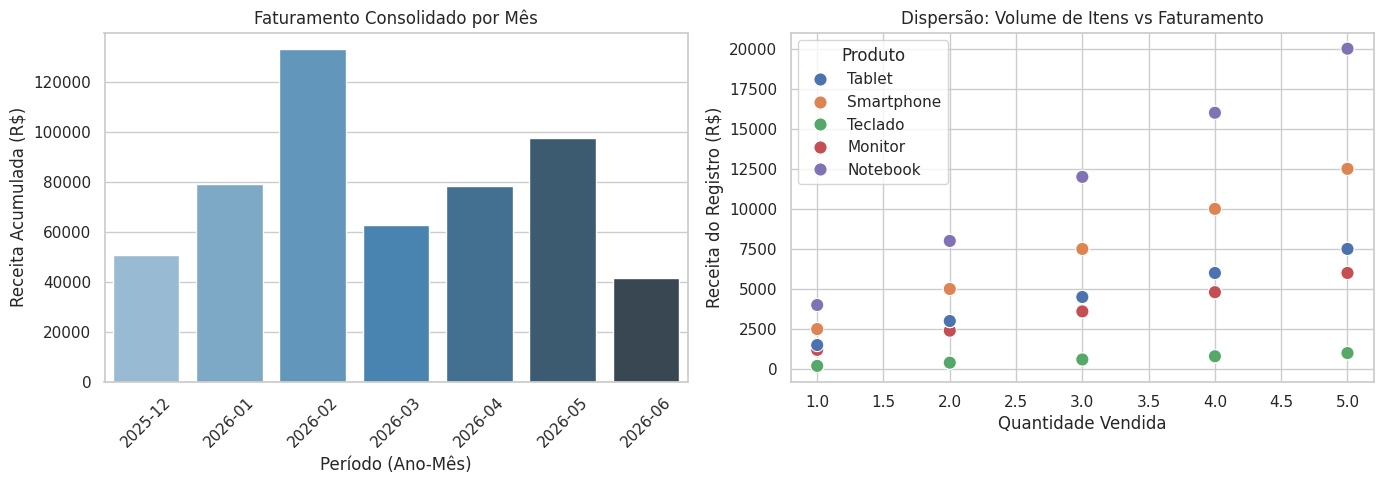


[Sucesso] Pipeline concluído! Arquivos CSV e JSON gerados no diretório.


In [17]:
# =====================================================================
# PASSO 1: BLOCO DE IMPORTAÇÃO DE BIBLIOTECAS (Obrigatório no topo)
# =====================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import random
from datetime import datetime, timedelta

# =====================================================================
# RF01 – CRIAR OU CARREGAR O DATASET DE VENDAS
# =====================================================================
def criar_dataset_vendas():
    """Gera um DataFrame simulado com 100 transações de vendas."""
    np.random.seed(42)
    random.seed(42)

    # Gerando dados fictícios básicos
    clientes = [f"CLI_{random.randint(1000, 1100)}" for _ in range(100)]
    produtos = random.choices(["Notebook", "Smartphone", "Tablet", "Monitor", "Teclado"], k=100)
    quantidades = np.random.randint(1, 6, size=100)

    precos_base = {"Notebook": 4000, "Smartphone": 2500, "Tablet": 1500, "Monitor": 1200, "Teclado": 200}
    precos_unitarios = [precos_base[p] for p in produtos]

    data_final = datetime.now()
    datas = [data_final - timedelta(days=int(np.random.randint(0, 180))) for _ in range(100)]

    df = pd.DataFrame({
        "ID_Cliente": clientes,
        "Produto": produtos,
        "Quantidade": quantidades,
        "Preco_Unitario": precos_unitarios,
        "Data_Venda": datas
    })

    # Inserindo valores nulos (NaN) artificiais para tratamento posterior
    df.loc[10, "Quantidade"] = np.nan
    df.loc[25, "Preco_Unitario"] = np.nan

    # Inserindo Outliers (valores discrepantes absurdos)
    df.loc[5, "Preco_Unitario"] = 50000
    df.loc[50, "Preco_Unitario"] = 35000

    return df

# =====================================================================
# RF02 – INSPECTIONAR E DESCREVER OS DADOS
# =====================================================================
def inspecionar_dados(df):
    """Exibe as estruturas iniciais e estatísticas básicas do dataset."""
    print("=== [RF02] Primeiras 5 linhas ===")
    display(df.head())
    print("\n=== [RF02] Informações do DataFrame ===")
    df.info()
    print("\n=== [RF02] Resumo Estatístico Inicial ===")
    display(df.describe())

# =====================================================================
# RF03 – LIMPAR E TRATAR OS DADOS
# =====================================================================
def limpar_dados(df):
    """Trata valores ausentes utilizando regras de negócio e Lambda."""
    df_limpo = df.copy()

    # Substitui Quantidade ausente por 1
    df_limpo["Quantidade"] = df_limpo["Quantidade"].fillna(1)

    # USO 1 DE LAMBDA: Preenche Preço ausente com a média do respectivo produto
    df_limpo["Preco_Unitario"] = df_limpo.groupby("Produto")["Preco_Unitario"].transform(
        lambda x: x.fillna(x.mean())
    )
    return df_limpo

# =====================================================================
# RF04 – DETECTAR E TRATAR OUTLIERS (VERSÕES V1 E V2)
# =====================================================================
def tratar_outliers_v1(df):
    """Versão 1: Detecta outliers via IQR e substitui pela mediana."""
    df_v1 = df.copy()
    Q1 = df_v1["Preco_Unitario"].quantile(0.25)
    Q3 = df_v1["Preco_Unitario"].quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + (1.5 * IQR)

    mediana = df_v1["Preco_Unitario"].median()
    df_v1.loc[df_v1["Preco_Unitario"] > limite_superior, "Preco_Unitario"] = mediana
    return df_v1

def tratar_outliers_v2(df):
    """Versão 2: Detecta outliers via Média + 3*Desvio e aplica Capping."""
    df_v2 = df.copy()
    media = df_v2["Preco_Unitario"].mean()
    desvio = df_v2["Preco_Unitario"].std()
    limite_superior = media + (3 * desvio)

    df_v2["Preco_Unitario"] = df_v2["Preco_Unitario"].clip(upper=limite_superior)
    return df_v2

# =====================================================================
# RF05 – CRIAR COLUNAS DERIVADAS COM TRANSFORMAÇÕES
# =====================================================================
def aplicar_transformacao(df, coluna, funcao_callback):
    """Aplica uma função customizada sobre uma coluna (Exigência técnica)."""
    return df[coluna].apply(funcao_callback)

def criar_colunas_derivadas(df):
    """Gera colunas calculadas necessárias para a análise preditiva."""
    df_derivado = df.copy()

    # Cálculo do faturamento individual por registro
    df_derivado["receita_total"] = df_derivado["Quantidade"] * df_derivado["Preco_Unitario"]
    df_derivado["Mes"] = df_derivado["Data_Venda"].dt.strftime("%Y-%m")

    # USO 2 DE LAMBDA: Classificação de Ticket Dinâmico (Atende critério de múltiplos Lambdas)
    df_derivado["Categoria_Ticket"] = aplicar_transformacao(
        df_derivado, "receita_total", lambda x: "Alto" if x > 3000 else "Normal"
    )
    return df_derivado

# =====================================================================
# RF06 & RF07 – METRICAS AGREGADAS E SEGMENTAÇÃO DE CLIENTES
# =====================================================================
def agrupar_e_segmentar(df):
    """Calcula agregados mensais e categoriza o valor por cliente."""
    # RF06: Agrupamento por Mês
    df_mensal = df.groupby("Mes")["receita_total"].sum().reset_index()

    # RF07: Agrupamento por Cliente e Segmentação RFM simplificada
    df_cliente_gasto = df.groupby("ID_Cliente")["receita_total"].sum().reset_index()

    # Definição das categorias com base nos limites de gastos
    def rotular_segmento(valor):
        if valor < 2000:
            return "Bronze"
        elif valor <= 5000:
            return "Prata"
        else:
            return "Ouro"

    df_cliente_gasto["Segmento"] = df_cliente_gasto["receita_total"].apply(rotular_segmento)
    return df_mensal, df_cliente_gasto

# =====================================================================
# RF08 – CALCULAR ESTATÍSTICAS COM NUMPY
# =====================================================================
def calcular_estatisticas_numpy(df):
    """Extrai métricas do vetor de preços utilizando funções NumPy."""
    valores_vetor = df["Preco_Unitario"].to_numpy()

    estatisticas = {
        "media_preco": float(np.mean(valores_vetor)),
        "mediana_preco": float(np.median(valores_vetor)),
        "desvio_padrao_preco": float(np.std(valores_vetor)),
        "total_registros_processados": int(len(df))
    }
    return estatisticas

# =====================================================================
# RF09 – CRIAR VISUALIZAÇÕES (MATPLOTLIB E SEABORN)
# =====================================================================
def plotar_visualizacoes(df_mensal, df_principal):
    """Gera painel visual de análise de faturamento e comportamento."""
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(14, 5))

    # Gráfico 1: Evolução Mensal (Barras)
    plt.subplot(1, 2, 1)
    sns.barplot(data=df_mensal, x="Mes", y="receita_total", palette="Blues_d")
    plt.title("Faturamento Consolidado por Mês")
    plt.xlabel("Período (Ano-Mês)")
    plt.ylabel("Receita Acumulada (R$)")
    plt.xticks(rotation=45)

    # Gráfico 2: Dispersão de Quantidade vs Receita Total
    plt.subplot(1, 2, 2)
    sns.scatterplot(data=df_principal, x="Quantidade", y="receita_total", hue="Produto", s=90)
    plt.title("Dispersão: Volume de Itens vs Faturamento")
    plt.xlabel("Quantidade Vendida")
    plt.ylabel("Receita do Registro (R$)")

    plt.tight_layout()
    plt.show()

# =====================================================================
# RF10, RF11 & RF12 – CONSOLIDAR E EXPORTAR ARQUIVOS
# =====================================================================
def executar_pipeline_analise():
    """Função Mestra: Orquestra toda a execução do projeto sequencialmente."""
    print("[Pipeline] Iniciando processamento dos dados...\n")

    # Execução das Etapas sequenciais
    df_bruto = criar_dataset_vendas()
    inspecionar_dados(df_bruto)

    df_limpo = limpar_dados(df_bruto)

    # Aplicação e validação do tratamento de outliers (Usando V1 conforme convenção)
    df_sem_outliers = tratar_outliers_v1(df_limpo)

    df_final = criar_colunas_derivadas(df_sem_outliers)
    df_mes, df_clientes = agrupar_e_segmentar(df_final)

    estatisticas = calcular_estatisticas_numpy(df_final)

    # Renderização das telas de relatórios visuais
    plotar_visualizacoes(df_mes, df_final)

    # Exportação dos arquivos finais requeridos
    df_final.to_csv("dataset_final.csv", index=False)
    df_mes.to_csv("metricas_por_mes.csv", index=False)
    df_clientes.to_csv("segmentacao_clientes.csv", index=False)

    with open("estatisticas_gerais.json", "w", encoding="utf-8") as f:
        json.dump(estatisticas, f, indent=4, ensure_ascii=False)

    print("\n[Sucesso] Pipeline concluído! Arquivos CSV e JSON gerados no diretório.")

# Execução do notebook
if __name__ == "__main__":
    executar_pipeline_analise()